# Silicon MZM Tutorial (O-band)

This notebook analyzes a surrogate silicon MZM over **1.26-1.36 um**.

In [1]:
import subprocess
import shutil
import os
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import gdsfactory as gf
gf.gpdk.PDK.activate()

from lightly_engineered.config import PhaseShifterConfig, StackConfig, MZMConfig
from lightly_engineered.pdk.cross_sections import xs_phase_shifter
from lightly_engineered.pdk.layer_stack import get_layer_stack
from lightly_engineered.layout.mzm import mzm
from lightly_engineered.models.phase_shifter import PhaseShifterCompact
from lightly_engineered.models.mzm import PushPullMZM
from lightly_engineered.models.tline import RLGCLine
from lightly_engineered.sim.optical_modes import solve_cross_section_modes
from lightly_engineered.sim.tcad import DevsimRunConfig, run_carrier_bias_sweep
from lightly_engineered.sim.electrostatics import extract_capacitance_sweep

## 1) Cross-section Figure of the Modulator Arm (gdsfactory objects)

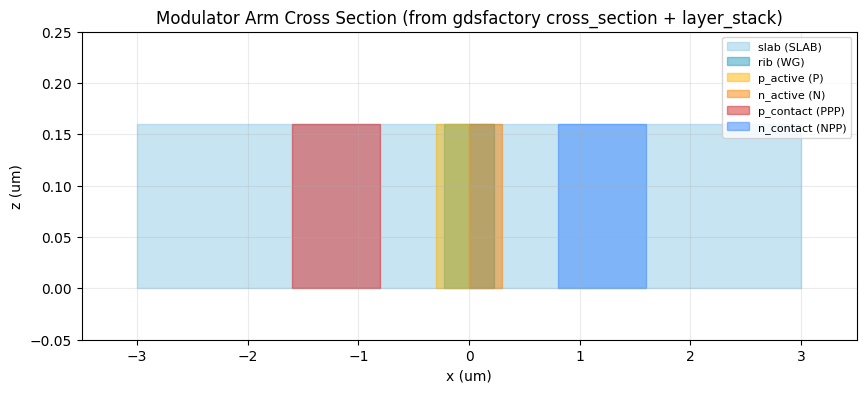

In [2]:
xs = xs_phase_shifter()
ls = get_layer_stack()

# Build a layer->(zmin, thickness) map from the gdsfactory LayerStack
layer_z = {}
for name, lvl in ls.layers.items():
    layer_z[tuple(lvl.layer)] = (lvl.zmin, lvl.thickness, name)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#8ecae6', '#219ebc', '#ffb703', '#fb8500', '#d62828', '#3a86ff']

for i, s in enumerate(xs.sections):
    lk = tuple(s.layer)
    if lk in layer_z:
        zmin, thick, lname = layer_z[lk]
    else:
        # Doped marker layers are not in default optical stack; plot as Si-height overlays
        zmin, thick, lname = 0.0, StackConfig().si_thickness_um, str(s.layer)
    x0 = s.offset - s.width / 2
    ax.add_patch(Rectangle((x0, zmin), s.width, thick, color=colors[i % len(colors)], alpha=0.5, label=f'{s.name} ({lname})'))

ax.set_title('Modulator Arm Cross Section (from gdsfactory cross_section + layer_stack)')
ax.set_xlabel('x (um)')
ax.set_ylabel('z (um)')
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-0.05, 0.25)
ax.grid(alpha=0.25)
h, l = ax.get_legend_handles_labels()
u = dict(zip(l, h))
ax.legend(u.values(), u.keys(), fontsize=8, loc='upper right')
plt.show()

## 2) MZM Layout

Component(name=mzm_MCNone_PCNone, ports=['o1', 'o2'], pins=[], instances=['mmi1x2_0_0', 'mmi2x1_2400000_0', 'phase_shifter_straight_L2000_CPhaseShifterConfigrib_wid_a51a59ed_200000_20000', 'phase_shifter_straight_L2000_CPhaseShifterConfigrib_wid_a51a59ed_200000_-20000', 'taper_gdsfactorypcomponentsptapersptaper_L10_W0p45_W0p5_19ae11f2_200000_20000_A180', 'taper_gdsfactorypcomponentsptapersptaper_L10_W0p45_W0p5_19ae11f2_200000_-20000_A180', 'taper_gdsfactorypcomponentsptapersptaper_L10_W0p45_W0p5_19ae11f2_2200000_20000', 'taper_gdsfactorypcomponentsptapersptaper_L10_W0p45_W0p5_19ae11f2_2200000_-20000', 'bend_euler_gdsfactorypcomponentspbendspbend_euler_R10_A_335c8724_25500_-9375_A90', 'bend_euler_gdsfactorypcomponentspbendspbend_euler_R10_A_335c8724_35500_-19375_A180_M', 'bend_euler_gdsfactorypcomponentspbendspbend_euler_R10_A_335c8724_45500_-9375_A270_M', 'bend_euler_gdsfactorypcomponentspbendspbend_euler_R10_A_335c8724_55500_20000_A180', 'straight_gdsfactorypcomponentspwaveguidespstra

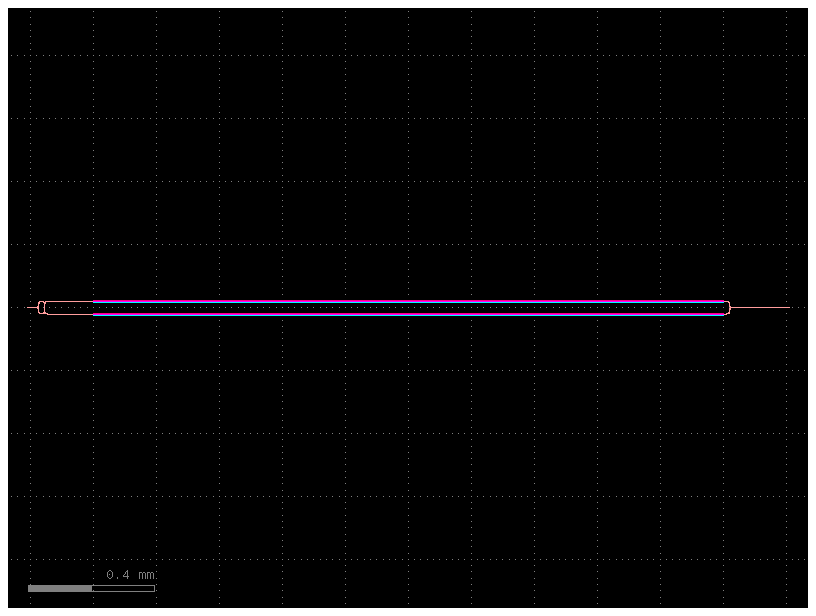

In [3]:
c = mzm()
print(c)
c.plot()

## 3) Mode Field Profile at O-band Center (1.31 um)

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmprg3rb62j/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmprg3rb62j/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmprg3rb62j/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmprg3rb62j/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 24 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 10%] 

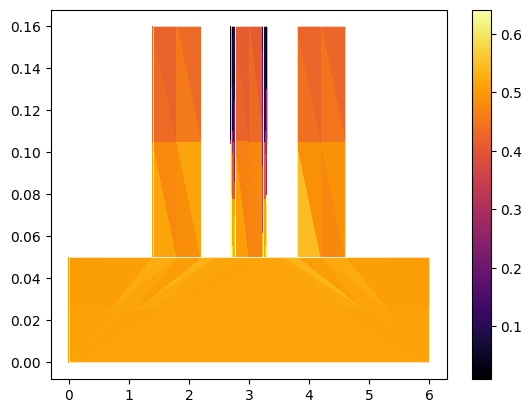

In [4]:
c0 = 299_792_458.0
wl0 = 1.31
f0_thz = (c0 / (wl0 * 1e-6)) / 1e12
mr = solve_cross_section_modes(wavelength_um=wl0, num_modes=1, include_doped_channels=True)
m0 = mr.raw.modes[0]
print(f'Center frequency: {f0_thz:.2f} THz')
print('neff:', complex(m0.n_eff))
m0.plot_intensity()
plt.show()

## 4) Effective Index and Group Index Across O-band

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpw5c__7_c/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpw5c__7_c/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpw5c__7_c/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpw5c__7_c/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%] Meshing curve 12 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 21 (Line)
Info    : [  0%] 

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp31ffimxy/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp31ffimxy/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp31ffimxy/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp31ffimxy/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 15 (Line)
Info    : [ 10%] Meshing curve 24 (Line)
Info    : [ 10%] 

Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpqfsstpwe/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpqfsstpwe/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpqfsstpwe/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpqfsstpwe/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%] Meshing curve 12 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 21 (Line)
Info    : [  0%] Meshing curve 6 (Line)
Info    : [  0%] Meshing curve 24 (Line)
Info    : [  0%] Meshing

Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpf1zwpux0/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpf1zwpux0/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpf1zwpux0/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpf1zwpux0/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 20 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 30%] Meshing c

Info    : Writing 'mesh.msh'...
Info    : Done writing 'mesh.msh'



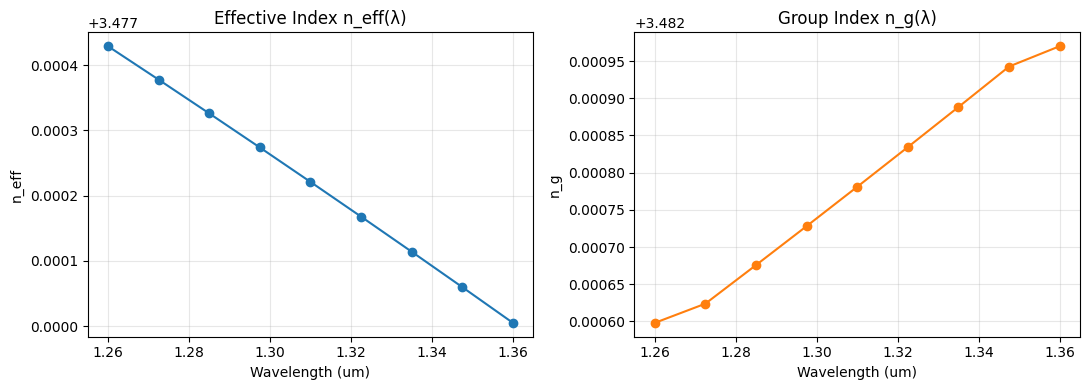

In [5]:
wl_um = np.linspace(1.26, 1.36, 9)
neff = []
for wl in wl_um:
    r = solve_cross_section_modes(wavelength_um=float(wl), num_modes=1, include_doped_channels=True)
    neff.append(np.real(r.neff[0]))
neff = np.asarray(neff)
ng = neff - wl_um * np.gradient(neff, wl_um)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(wl_um, neff, 'o-')
ax[0].set_title('Effective Index n_eff(λ)')
ax[0].set_xlabel('Wavelength (um)')
ax[0].set_ylabel('n_eff')
ax[0].grid(alpha=0.3)

ax[1].plot(wl_um, ng, 'o-', color='tab:orange')
ax[1].set_title('Group Index n_g(λ)')
ax[1].set_xlabel('Wavelength (um)')
ax[1].set_ylabel('n_g')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Electrostatic Contact Parameters as a Function of Frequency

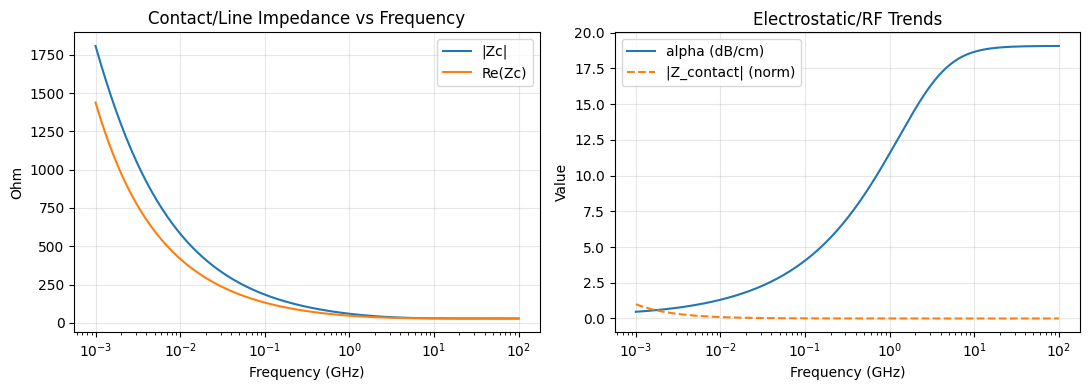

In [6]:
mzm_cfg = MZMConfig()
vgrid = np.linspace(-2.0, 2.0, 41)
tcad = run_carrier_bias_sweep(voltage_v=vgrid, backend='surrogate')
es = extract_capacitance_sweep(voltage_v=vgrid, backend='surrogate')

r_per_m = float(np.mean(tcad.r_per_m))
c_per_m = float(np.mean(es.c_per_m))
line = RLGCLine(r_per_m=r_per_m, l_per_m=0.45e-6, g_per_m=1e-3, c_per_m=c_per_m)

f_hz = np.logspace(6, 11, 250)
w = 2*np.pi*f_hz
gamma = line.gamma(w)
zc = line.zc(w)
alpha_db_per_cm = np.real(gamma) * 8.686 / 100.0

l_dev = mzm_cfg.phase_shifter_length_um * 1e-6
r_tot = r_per_m * l_dev
c_tot = c_per_m * l_dev
z_contact = np.abs(r_tot + 1/(1j*w*c_tot))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(f_hz/1e9, np.abs(zc), label='|Zc|')
ax[0].semilogx(f_hz/1e9, np.real(zc), label='Re(Zc)')
ax[0].set_title('Contact/Line Impedance vs Frequency')
ax[0].set_xlabel('Frequency (GHz)')
ax[0].set_ylabel('Ohm')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].semilogx(f_hz/1e9, alpha_db_per_cm, label='alpha (dB/cm)')
ax[1].semilogx(f_hz/1e9, z_contact/np.max(z_contact), '--', label='|Z_contact| (norm)')
ax[1].set_title('Electrostatic/RF Trends')
ax[1].set_xlabel('Frequency (GHz)')
ax[1].set_ylabel('Value')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6) Expected Frequency Response of the Modulator

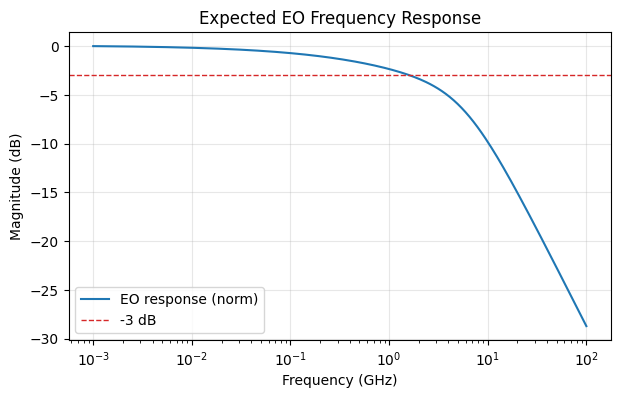

Estimated RC f3dB = 5.63 GHz


In [7]:
h_line = np.abs(np.exp(-gamma * l_dev))
f3db_rc = 1.0 / (2*np.pi*r_tot*c_tot)
h_rc = 1.0 / np.sqrt(1 + (f_hz/f3db_rc)**2)
h_eo = (h_line / h_line[0]) * h_rc
h_eo_db = 20*np.log10(np.maximum(h_eo, 1e-12))

plt.figure(figsize=(7,4))
plt.semilogx(f_hz/1e9, h_eo_db, label='EO response (norm)')
plt.axhline(-3, color='tab:red', linestyle='--', linewidth=1, label='-3 dB')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.title('Expected EO Frequency Response')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'Estimated RC f3dB = {f3db_rc/1e9:.2f} GHz')

## 7) Insertion Loss and Extinction vs Wavelength

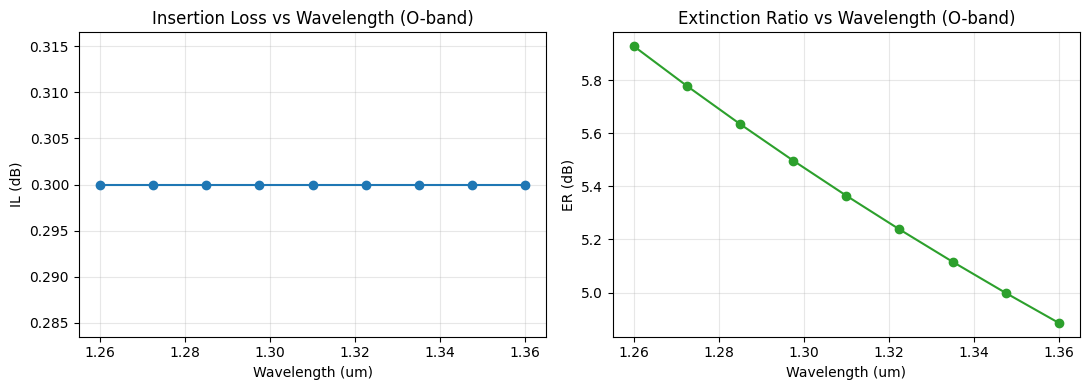

In [8]:
vdrive = np.linspace(-2.0, 2.0, 201)
dn = tcad.delta_neff_real
dalpha_db_cm = tcad.delta_loss_db_per_cm
passive_loss_db_cm = 1.5
length_cm = mzm_cfg.phase_shifter_length_um * 1e-4

il = []
er = []
for wl, neff0 in zip(wl_um, neff):
    neff_grid = neff0 + dn + 1j*(dalpha_db_cm/8.686)
    ps_model = PhaseShifterCompact(
        wavelength_um=float(wl),
        length_um=mzm_cfg.phase_shifter_length_um,
        voltage_grid=vgrid,
        neff_grid=neff_grid,
        loss_grid_db_per_cm=dalpha_db_cm,
        c_per_m=c_per_m,
        r_per_m=r_per_m,
    )
    dev = PushPullMZM(top=ps_model, bot=ps_model, rf_line=line)
    t = np.array([dev.transmission(v) for v in vdrive])
    tmax = float(np.max(t))
    tmin = float(np.min(t))
    il.append(-10*np.log10(max(tmax, 1e-12)) + passive_loss_db_cm*length_cm)
    er.append(10*np.log10(max(tmax, 1e-12)/max(tmin, 1e-12)))

il = np.asarray(il)
er = np.asarray(er)

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(wl_um, il, 'o-')
ax[0].set_title('Insertion Loss vs Wavelength (O-band)')
ax[0].set_xlabel('Wavelength (um)')
ax[0].set_ylabel('IL (dB)')
ax[0].grid(alpha=0.3)

ax[1].plot(wl_um, er, 'o-', color='tab:green')
ax[1].set_title('Extinction Ratio vs Wavelength (O-band)')
ax[1].set_xlabel('Wavelength (um)')
ax[1].set_ylabel('ER (dB)')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8) VpiL Extraction for the Modulator Cross Section

Compute `VπL` at O-band center from the bias-dependent phase shift. The cell uses DEVSIM results when `outputs/devsim_sweep.json` exists; otherwise it falls back to the surrogate TCAD sweep.


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpks7j_4k9/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpks7j_4k9/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpks7j_4k9/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpks7j_4k9/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 24 (Line)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 30%] Me

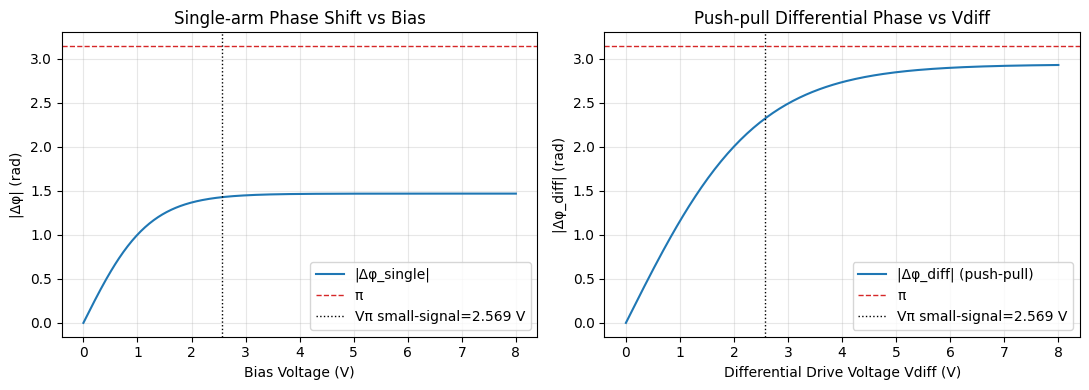

TCAD backend used: surrogate
Single-arm (small-signal extrapolation): Vpi=2.5689 V, VpiL=0.5138 V·cm (L=0.200 cm)
Push-pull differential (small-signal extrapolation): Vpi=2.5689 V, VpiL=0.5138 V·cm (L=0.200 cm)


In [9]:
wl_vpil = 1.31
vref = 0.0
v_single = np.linspace(0.0, 8.0, 801)
vdiff = np.linspace(0.0, 8.0, 801)

# Prefer DEVSIM data if available.
devsim_file = Path('outputs/devsim_sweep.json')
if devsim_file.exists():
    tcad_vpil = run_carrier_bias_sweep(
        voltage_v=np.linspace(-8.0, 8.0, 801),
        backend='devsim',
        devsim=DevsimRunConfig(results_file=devsim_file),
    )
    tcad_backend_used = f"devsim ({devsim_file})"
else:
    tcad_vpil = run_carrier_bias_sweep(voltage_v=np.linspace(-8.0, 8.0, 801), backend='surrogate')
    tcad_backend_used = 'surrogate'

opt_vpil = solve_cross_section_modes(wavelength_um=wl_vpil, num_modes=1, include_doped_channels=True)
neff0_vpil = np.real(opt_vpil.neff[0])
neff_grid_vpil = neff0_vpil + tcad_vpil.delta_neff_real + 1j * (tcad_vpil.delta_loss_db_per_cm / 8.686)

ps_vpil = PhaseShifterCompact(
    wavelength_um=wl_vpil,
    length_um=mzm_cfg.phase_shifter_length_um,
    voltage_grid=tcad_vpil.voltage_v,
    neff_grid=neff_grid_vpil,
    loss_grid_db_per_cm=tcad_vpil.delta_loss_db_per_cm,
    c_per_m=c_per_m,
    r_per_m=float(np.mean(tcad_vpil.r_per_m)),
)

phi_single = np.array([ps_vpil.delta_phase(v, vref=vref) for v in v_single])
phi_pushpull = np.array([
    ps_vpil.delta_phase(0.5 * v, vref=vref) - ps_vpil.delta_phase(-0.5 * v, vref=vref)
    for v in vdiff
])

def interp_v_at_pi(v, phi):
    aphi = np.abs(phi)
    if np.max(aphi) < np.pi:
        return np.nan
    return float(np.interp(np.pi, aphi, v))

def small_signal_vpi(v, phi):
    # slope of |phase| around 0 V
    k = np.gradient(np.abs(phi), v)[0]
    if k <= 0:
        return np.nan
    return float(np.pi / k)

vpi_single_direct = interp_v_at_pi(v_single, phi_single)
vpi_pushpull_direct = interp_v_at_pi(vdiff, phi_pushpull)

vpi_single_ss = small_signal_vpi(v_single, phi_single)
vpi_pushpull_ss = small_signal_vpi(vdiff, phi_pushpull)

vpi_single = vpi_single_direct if np.isfinite(vpi_single_direct) else vpi_single_ss
vpi_pushpull = vpi_pushpull_direct if np.isfinite(vpi_pushpull_direct) else vpi_pushpull_ss

length_cm = mzm_cfg.phase_shifter_length_um * 1e-4
vpil_single = vpi_single * length_cm
vpil_pushpull = vpi_pushpull * length_cm

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(v_single, np.abs(phi_single), label='|Δφ_single|')
ax[0].axhline(np.pi, color='tab:red', linestyle='--', linewidth=1, label='π')
if np.isfinite(vpi_single_direct):
    ax[0].axvline(vpi_single_direct, color='k', linestyle=':', linewidth=1, label=f'Vπ direct={vpi_single_direct:.3f} V')
else:
    ax[0].axvline(vpi_single_ss, color='k', linestyle=':', linewidth=1, label=f'Vπ small-signal={vpi_single_ss:.3f} V')
ax[0].set_title('Single-arm Phase Shift vs Bias')
ax[0].set_xlabel('Bias Voltage (V)')
ax[0].set_ylabel('|Δφ| (rad)')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(vdiff, np.abs(phi_pushpull), label='|Δφ_diff| (push-pull)')
ax[1].axhline(np.pi, color='tab:red', linestyle='--', linewidth=1, label='π')
if np.isfinite(vpi_pushpull_direct):
    ax[1].axvline(vpi_pushpull_direct, color='k', linestyle=':', linewidth=1, label=f'Vπ direct={vpi_pushpull_direct:.3f} V')
else:
    ax[1].axvline(vpi_pushpull_ss, color='k', linestyle=':', linewidth=1, label=f'Vπ small-signal={vpi_pushpull_ss:.3f} V')
ax[1].set_title('Push-pull Differential Phase vs Vdiff')
ax[1].set_xlabel('Differential Drive Voltage Vdiff (V)')
ax[1].set_ylabel('|Δφ_diff| (rad)')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

single_method = 'direct pi crossing' if np.isfinite(vpi_single_direct) else 'small-signal extrapolation'
pp_method = 'direct pi crossing' if np.isfinite(vpi_pushpull_direct) else 'small-signal extrapolation'

print(f'TCAD backend used: {tcad_backend_used}')
print(f'Single-arm ({single_method}): Vpi={vpi_single:.4f} V, VpiL={vpil_single:.4f} V·cm (L={length_cm:.3f} cm)')
print(f'Push-pull differential ({pp_method}): Vpi={vpi_pushpull:.4f} V, VpiL={vpil_pushpull:.4f} V·cm (L={length_cm:.3f} cm)')


## 8.5) Run DEVSIM Sweep from Notebook (Optional)

Set `run_devsim = True` to execute a DEVSIM deck directly from this notebook and write `outputs/devsim_sweep.json` for downstream cells.


In [10]:
run_devsim = False

devsim_exe = shutil.which('devsim')
devsim_script = Path('scripts/devsim_pn_sweep.py')  # your DEVSIM deck script
devsim_out = Path('outputs/devsim_sweep.json')
voltage_for_deck = np.linspace(-2.0, 2.0, 41)

if run_devsim:
    if devsim_exe is None:
        raise RuntimeError('DEVSIM executable not found in PATH. Install DEVSIM and retry.')
    if not devsim_script.exists():
        raise FileNotFoundError(
            f'DEVSIM script not found: {devsim_script}. Create this deck script first.'
        )

    env = os.environ.copy()
    env['LE_DEVSIM_OUT'] = str(devsim_out)
    env['LE_VOLTAGE_GRID'] = ','.join(f'{v:.6g}' for v in voltage_for_deck)

    cmd = [devsim_exe, str(devsim_script)]
    print('Running:', ' '.join(cmd))
    print('LE_DEVSIM_OUT=', env['LE_DEVSIM_OUT'])
    print('LE_VOLTAGE_GRID=', env['LE_VOLTAGE_GRID'])
    subprocess.run(cmd, check=True, env=env)

    if not devsim_out.exists():
        raise RuntimeError(f'DEVSIM finished but did not write expected output: {devsim_out}')
    print(f'Wrote {devsim_out}')
else:
    print('DEVSIM run skipped. Set run_devsim=True to execute your DEVSIM deck from notebook.')


DEVSIM run skipped. Set run_devsim=True to execute your DEVSIM deck from notebook.


## 9) Mode Index Sensitivity vs Voltage and Wavelength

This section computes `n_eff(V, λ)` and sensitivity `∂n_eff/∂V`. If `outputs/devsim_femwell_neff_sweep.json` is present (from DEVSIM carrier profiles post-processed in FEMWELL), it uses that directly; otherwise it runs a surrogate fallback for continuity.


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpnw_ou5r4/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpnw_ou5r4/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpnw_ou5r4/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpnw_ou5r4/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 21 (Line)
Info    : [  0%] Meshing curve 22 (Line)
Info    : [  0%] Meshing curve 24 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%]

Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpsowfqceb/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpsowfqceb/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpsowfqceb/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpsowfqceb/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 15 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing cur

Info    : Clearing all models and views...
Info    : Done clearing all models and views


Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp_pa60lsn/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp_pa60lsn/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp_pa60lsn/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmp_pa60lsn/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [ 20%] Meshing c

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 10%] Meshing curve 24 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 22 (Line)
Info    : [ 30%] Meshing curve 25 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 9 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 16 (Line)
I

Info    : Writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpo587y9kc/temp.xao'...
Info    : Done writing '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpo587y9kc/temp.xao'
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpo587y9kc/temp.xao'...
Info    : Done reading '/var/folders/q6/yr49sjxd1xv60f5mmf5_vky00000gp/T/tmpo587y9kc/temp.xao'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [  0%] Meshing curve 17 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 20 (Line)
Info    : [  0%] Meshing curve 23 (Line)
Info    : [  0%] Meshing curve 18 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 24 (Line)
Info    : [ 10%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 9 (Line)
Info    : [ 30%] Meshing c

Info    : Writing 'mesh.msh'...
Info    : Done writing 'mesh.msh'



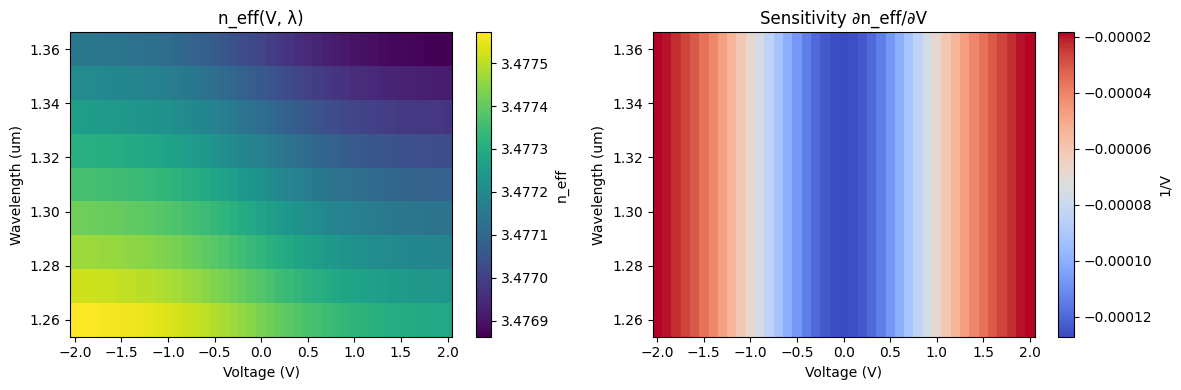

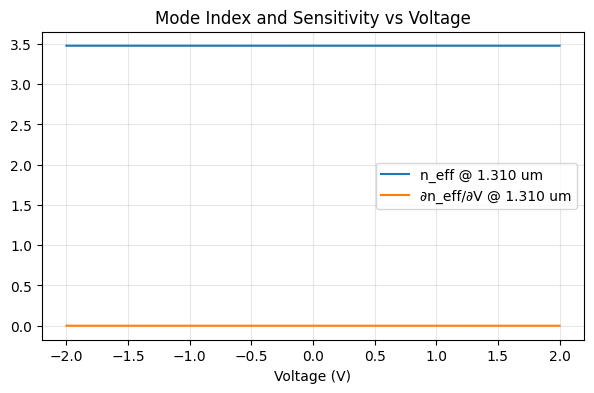

Sensitivity source: surrogate fallback (replace with devsim_femwell_neff_sweep.json)
At λ=1.310 um, V=0.000 V: ∂n_eff/∂V = -1.2721e-04 1/V
Small-signal single-arm VpiL ≈ 0.5149 V·cm
Small-signal push-pull VpiL ≈ 0.2575 V·cm


In [11]:
sweep_file = Path('outputs/devsim_femwell_neff_sweep.json')

if sweep_file.exists():
    payload = json.loads(sweep_file.read_text())
    wl_sens = np.asarray(payload['wavelength_um'], dtype=float)
    v_sens = np.asarray(payload['voltage_v'], dtype=float)
    neff_sens = np.asarray(payload['neff_real'], dtype=float)
    sensitivity_source = f'devsim+femwell ({sweep_file})'
else:
    wl_sens = np.linspace(1.26, 1.36, 9)
    v_sens = np.linspace(-2.0, 2.0, 41)
    tcad_sens = run_carrier_bias_sweep(voltage_v=v_sens, backend='surrogate')
    neff_sens = []
    for wl in wl_sens:
        r = solve_cross_section_modes(wavelength_um=float(wl), num_modes=1, include_doped_channels=True)
        neff_sens.append(np.real(r.neff[0]) + tcad_sens.delta_neff_real)
    neff_sens = np.asarray(neff_sens)
    sensitivity_source = 'surrogate fallback (replace with devsim_femwell_neff_sweep.json)'

dneff_dv = np.gradient(neff_sens, v_sens, axis=1)

# central O-band summary around 1.31 um and 0 V
iwl = int(np.argmin(np.abs(wl_sens - 1.31)))
iv0 = int(np.argmin(np.abs(v_sens - 0.0)))
k0 = float(dneff_dv[iwl, iv0])

length_cm = mzm_cfg.phase_shifter_length_um * 1e-4
if np.abs(k0) > 0:
    vpil_single_ss = (wl_sens[iwl] * 1e-4) / (2 * np.abs(k0))
    vpil_pushpull_ss = vpil_single_ss / 2
else:
    vpil_single_ss = np.nan
    vpil_pushpull_ss = np.nan

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

im0 = ax[0].pcolormesh(v_sens, wl_sens, neff_sens, shading='auto', cmap='viridis')
ax[0].set_title('n_eff(V, λ)')
ax[0].set_xlabel('Voltage (V)')
ax[0].set_ylabel('Wavelength (um)')
plt.colorbar(im0, ax=ax[0], label='n_eff')

im1 = ax[1].pcolormesh(v_sens, wl_sens, dneff_dv, shading='auto', cmap='coolwarm')
ax[1].set_title('Sensitivity ∂n_eff/∂V')
ax[1].set_xlabel('Voltage (V)')
ax[1].set_ylabel('Wavelength (um)')
plt.colorbar(im1, ax=ax[1], label='1/V')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(v_sens, neff_sens[iwl, :], label=f'n_eff @ {wl_sens[iwl]:.3f} um')
plt.plot(v_sens, dneff_dv[iwl, :], label=f'∂n_eff/∂V @ {wl_sens[iwl]:.3f} um')
plt.xlabel('Voltage (V)')
plt.grid(alpha=0.3)
plt.legend()
plt.title('Mode Index and Sensitivity vs Voltage')
plt.show()

print(f'Sensitivity source: {sensitivity_source}')
print(f'At λ={wl_sens[iwl]:.3f} um, V={v_sens[iv0]:.3f} V: ∂n_eff/∂V = {k0:.4e} 1/V')
print(f'Small-signal single-arm VpiL ≈ {vpil_single_ss:.4f} V·cm')
print(f'Small-signal push-pull VpiL ≈ {vpil_pushpull_ss:.4f} V·cm')
